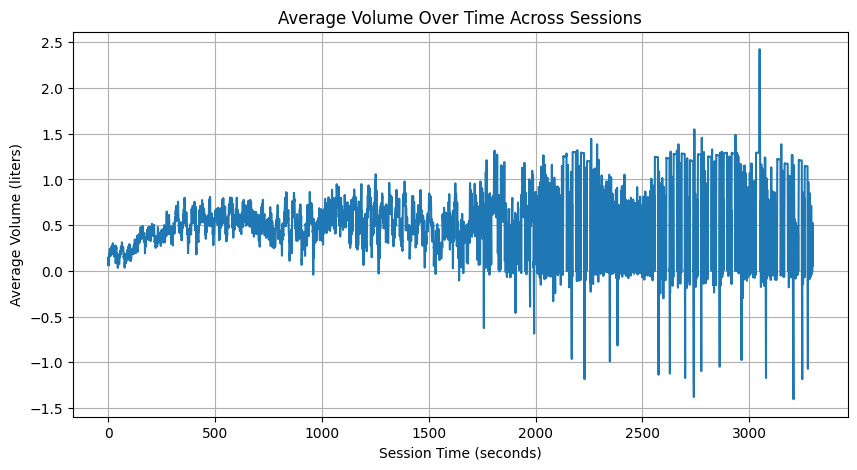

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

def process_curve_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Find the start of curve data
    data_start = None
    for i, line in enumerate(lines):
        if "HeaderEnd" in line:
            data_start = i + 1
            break
    
    if data_start is None:
        print(f"Error: No data found in {file_path}")
        return None
    
    # Read and process curve data
    data = []
    for line in lines[data_start:]:
        parts = line.strip().split(";")
        if len(parts) < 2:  
            continue
        try:
            session_time = float(parts[0])  
            volume = float(parts[1])  
            data.append([session_time, volume])
        except ValueError:
            continue  

    # Convert to DataFrame
    df = pd.DataFrame(data, columns=["Session Time", "Volume"])
    
    if df.empty:
        print(f"Warning: No valid data in {file_path}")
        return None

    # Normalize session time to start from zero
    df["Session Time"] -= df["Session Time"].min()

    # Round session time to 2 decimal places to avoid floating-point issues
    df["Session Time"] = df["Session Time"].round(2)
    
    return df

# Process all `.dat` files in the directory
file_pattern = "./*.dat"  # Change if in a subfolder
file_list = glob.glob(file_pattern)

all_data = []
for file_path in file_list:
    df = process_curve_data(file_path)
    if df is not None:
        all_data.append(df)

if all_data:
    combined_df = pd.concat(all_data)

    # Group by session time and compute mean volume
    avg_df = combined_df.groupby("Session Time", as_index=False)["Volume"].mean()

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(avg_df["Session Time"], avg_df["Volume"], linestyle='-')
    plt.xlabel("Session Time (seconds)")
    plt.ylabel("Average Volume (liters)")
    plt.title("Average Volume Over Time Across Sessions")
    plt.grid()
    plt.show()

In [2]:
output_file = "average_volume.dat"
avg_df.to_csv(output_file, sep=";", index=False)

print(f"Saved results to {output_file}")


Saved results to average_volume.dat


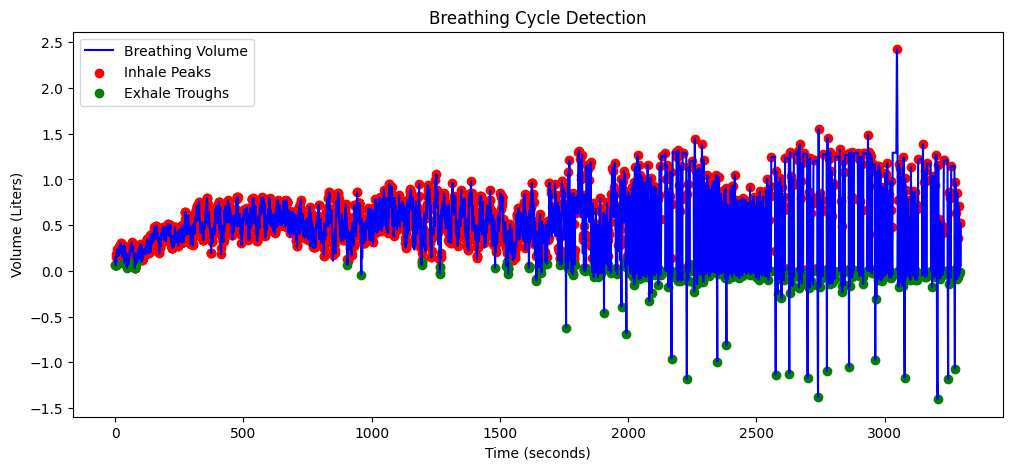

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the .dat file (fixing delimiter and column names)
file_path = "average_volume_afsana.dat"
data = pd.read_csv(file_path, delimiter=";", names=["time", "volume"], skiprows=1)  # Skip header row

# Ensure 'time' and 'volume' are numeric
data["time"] = pd.to_numeric(data["time"], errors="coerce")
data["volume"] = pd.to_numeric(data["volume"], errors="coerce")

# Sort data by time (ensuring sequential order)
data = data.sort_values(by="time").reset_index(drop=True)
from scipy.signal import find_peaks

# Find peaks (inhale points)
peaks, _ = find_peaks(data["volume"], height=0)

# Find troughs (exhale points)
troughs, _ = find_peaks(-data["volume"], height=-0.1)

# Plot with detected peaks and troughs
plt.figure(figsize=(12, 5))
plt.plot(data["time"], data["volume"], label="Breathing Volume", color="blue")
plt.scatter(data["time"][peaks], data["volume"][peaks], color="red", label="Inhale Peaks")
plt.scatter(data["time"][troughs], data["volume"][troughs], color="green", label="Exhale Troughs")
plt.xlabel("Time (seconds)")
plt.ylabel("Volume (Liters)")
plt.title("Breathing Cycle Detection")
plt.legend()
plt.show()


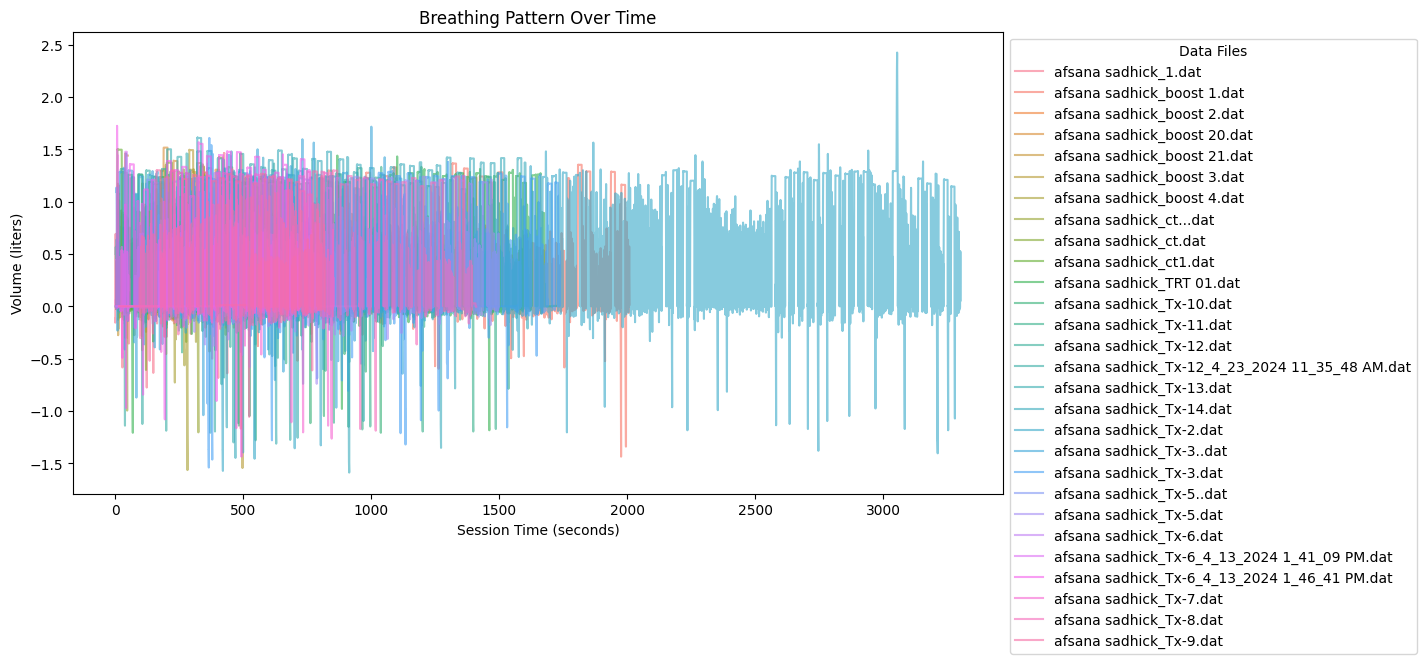

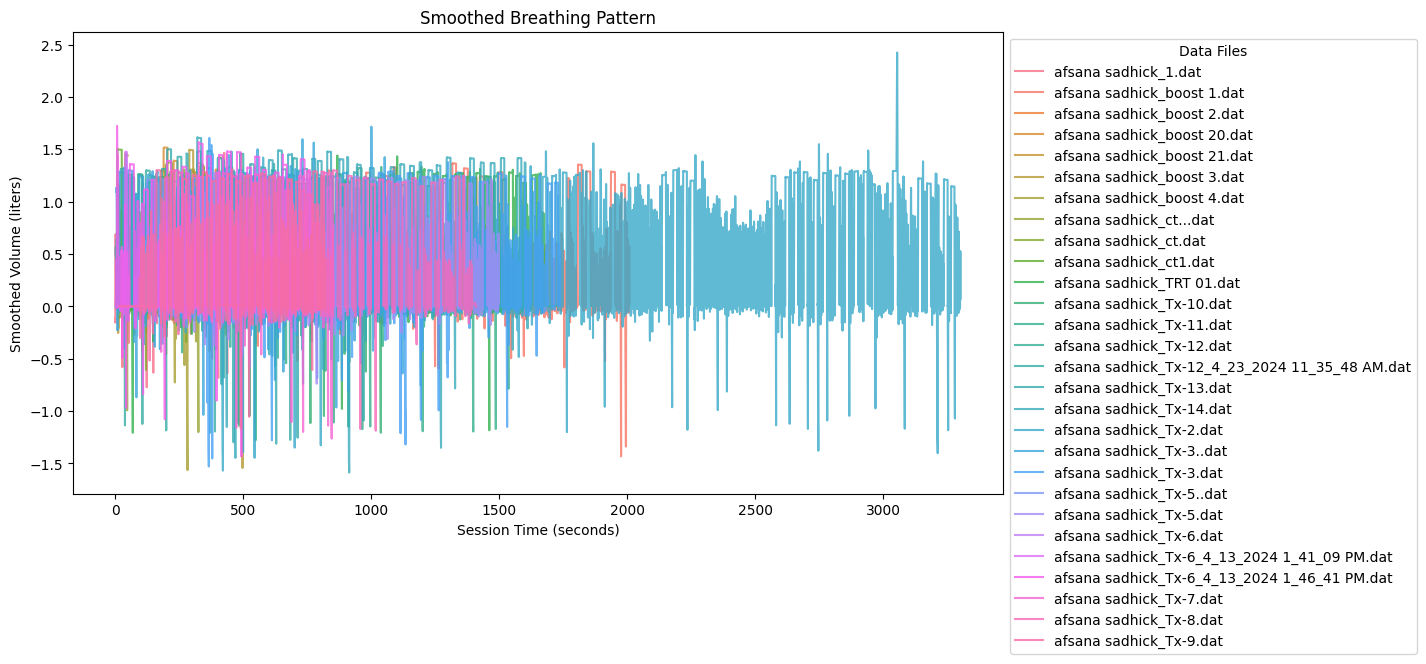

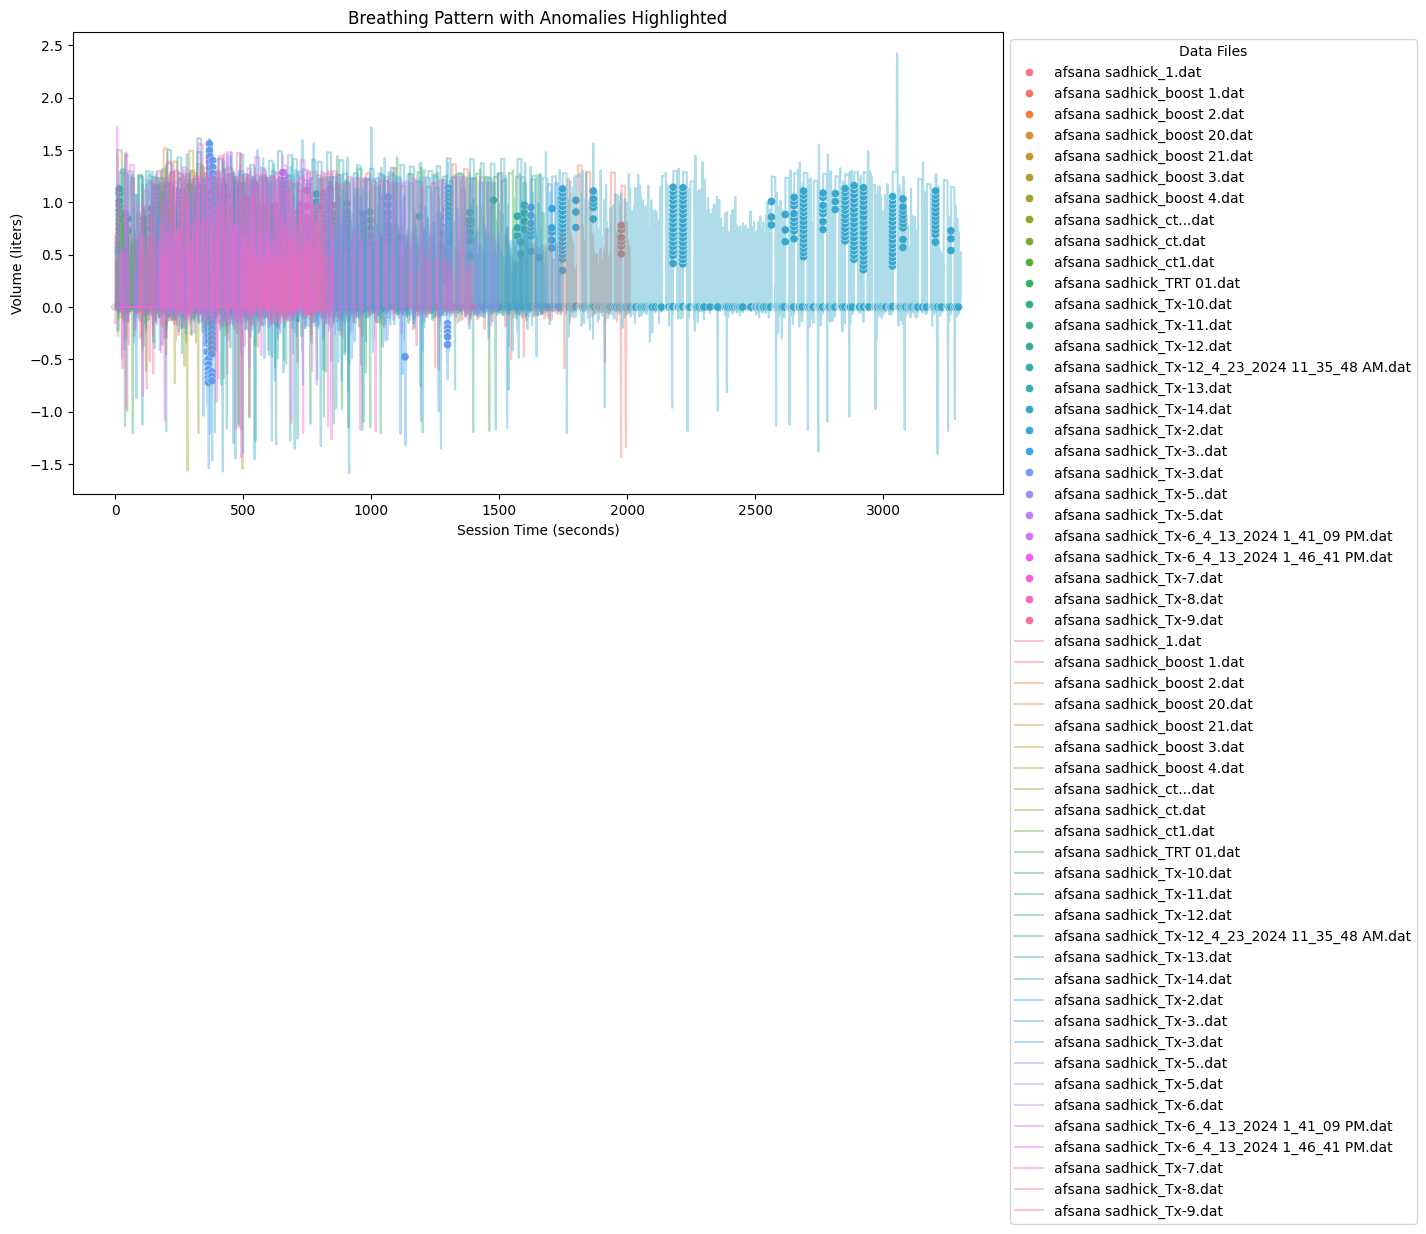

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Function to load a single .dat file
def load_dat_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract the header and data
    data = []
    is_header = True

    for line in lines:
        if line.strip() == 'HeaderEnd':
            is_header = False
            continue
        if not is_header:
            data.append(line.strip())

    # Convert data to DataFrame
    data = [line.split(';') for line in data if line]
    df = pd.DataFrame(data, columns=['Session Time', 'Volume (liters)', 'Balloon Valve Status', 'Patient Switch', 'Gating Mode', 'Gating Status', 'Relay State'])

    # Convert columns to appropriate data types
    df['Session Time'] = df['Session Time'].astype(float)
    df['Volume (liters)'] = df['Volume (liters)'].astype(float)
    df['Balloon Valve Status'] = pd.to_numeric(df['Balloon Valve Status'], errors='coerce')

    # Add filename as a column for identifying different files
    df['File'] = os.path.basename(file_path)
    
    return df

# Load all .dat files in the directory
files = glob.glob("*.dat")  # Change this path if needed
all_data = pd.concat([load_dat_file(f) for f in files], ignore_index=True)

# Visualization - Time Series of Volume
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_data, x='Session Time', y='Volume (liters)', hue='File', alpha=0.6)
plt.xlabel("Session Time (seconds)")
plt.ylabel("Volume (liters)")
plt.title("Breathing Pattern Over Time")
plt.legend(title="Data Files", bbox_to_anchor=(1, 1))
plt.show()

# Rolling Average for Smoother Pattern
all_data['Smoothed Volume'] = all_data.groupby('File')['Volume (liters)'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Plot Smoothed Volume
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_data, x='Session Time', y='Smoothed Volume', hue='File', alpha=0.8)
plt.xlabel("Session Time (seconds)")
plt.ylabel("Smoothed Volume (liters)")
plt.title("Smoothed Breathing Pattern")
plt.legend(title="Data Files", bbox_to_anchor=(1, 1))
plt.show()

# Find breathing pattern anomalies
all_data['Volume Change'] = all_data.groupby('File')['Volume (liters)'].diff()
outliers = all_data[all_data['Volume Change'].abs() > all_data['Volume Change'].std() * 2]

# Highlight outliers in the breathing pattern
plt.figure(figsize=(12, 6))
sns.scatterplot(data=outliers, x='Session Time', y='Volume (liters)', hue='File', color='red', marker='o')
sns.lineplot(data=all_data, x='Session Time', y='Volume (liters)', hue='File', alpha=0.4)
plt.xlabel("Session Time (seconds)")
plt.ylabel("Volume (liters)")
plt.title("Breathing Pattern with Anomalies Highlighted")
plt.legend(title="Data Files", bbox_to_anchor=(1, 1))
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_1364\4186478794.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat([load_dat_file(f) for f in files], ignore_index=True)


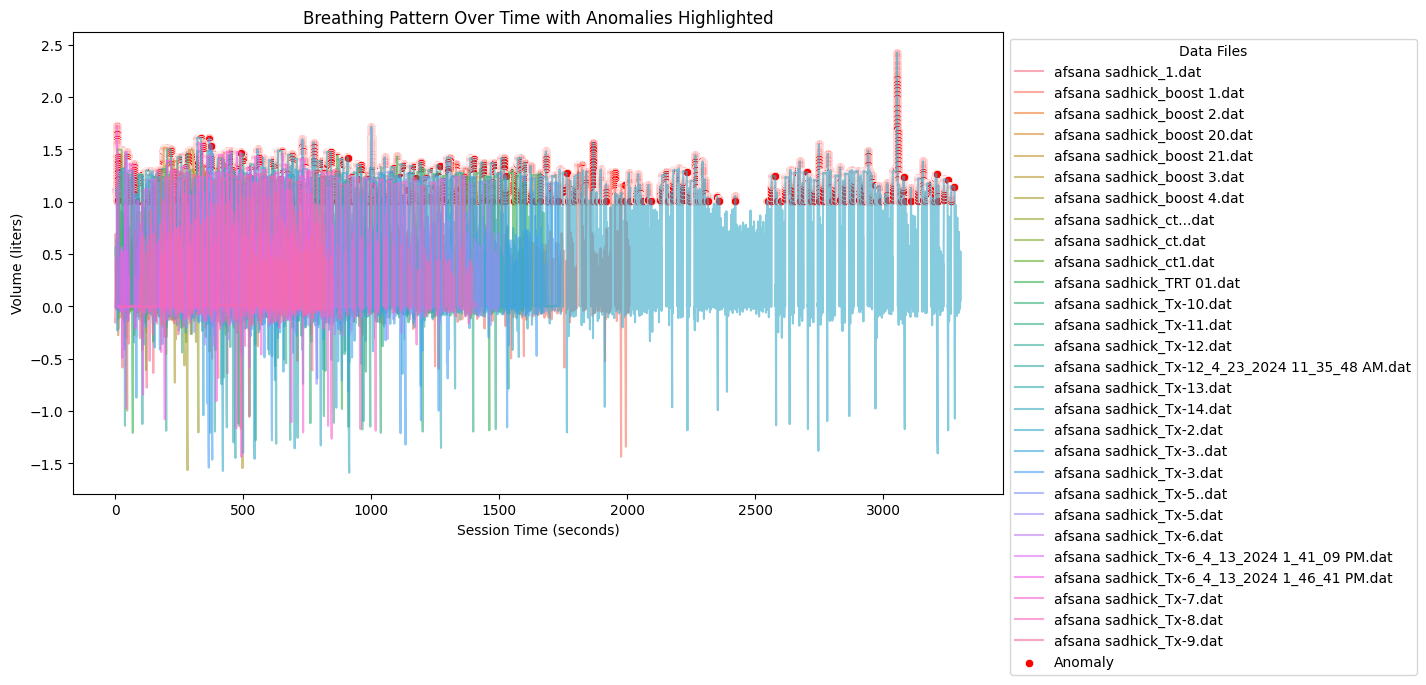

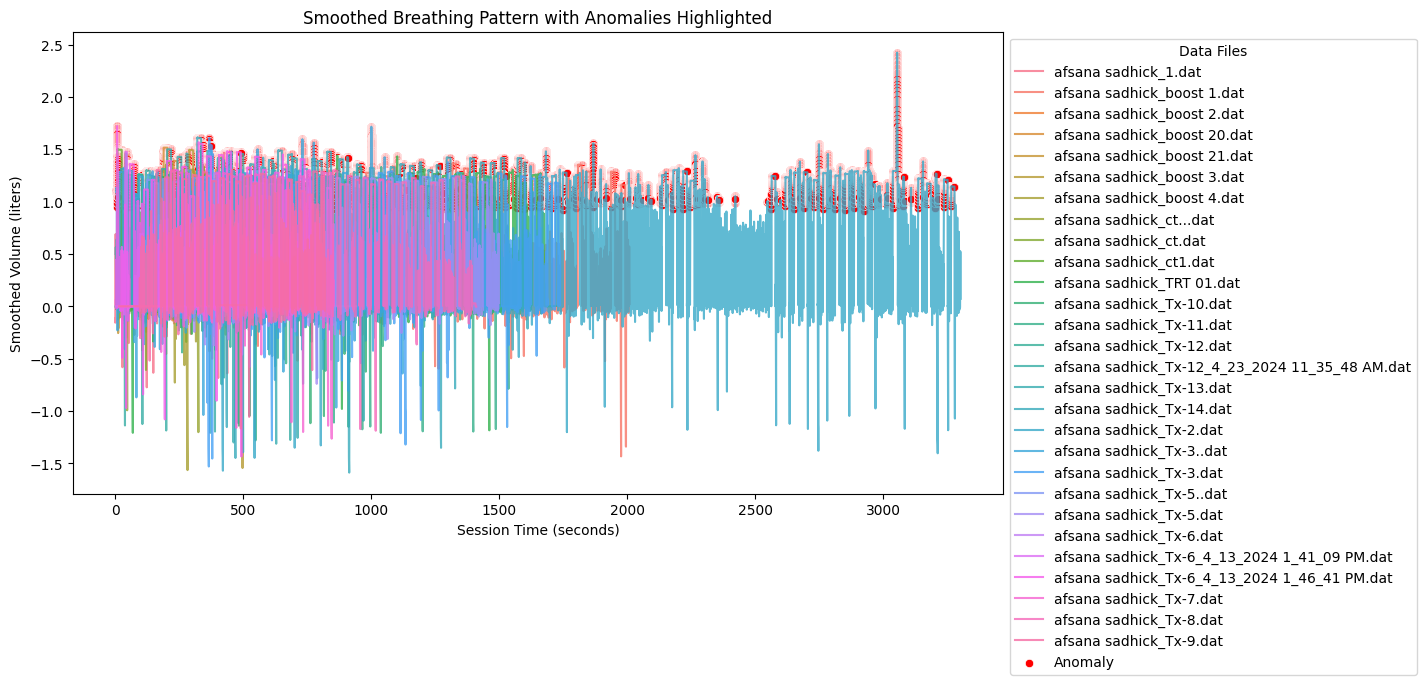

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Function to load a single .dat file and extract its threshold
def load_dat_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract threshold from the header
    threshold = None
    data = []
    is_header = True

    for line in lines:
        if "Threshold:" in line:  # Adjust based on your file format
            threshold = float(line.split(":")[-1].strip())  # Extract threshold value
        if line.strip() == 'HeaderEnd':
            is_header = False
            continue
        if not is_header:
            data.append(line.strip())

    # Convert data to DataFrame
    data = [line.split(';') for line in data if line]
    df = pd.DataFrame(data, columns=['Session Time', 'Volume (liters)', 'Balloon Valve Status', 'Patient Switch', 'Gating Mode', 'Gating Status', 'Relay State'])

    # Convert columns to appropriate data types
    df['Session Time'] = df['Session Time'].astype(float)
    df['Volume (liters)'] = df['Volume (liters)'].astype(float)
    df['Balloon Valve Status'] = pd.to_numeric(df['Balloon Valve Status'], errors='coerce')

    # Add filename and threshold as new columns
    df['File'] = os.path.basename(file_path)
    df['Threshold'] = threshold  # Store threshold

    return df

# Load all .dat files in the directory
files = glob.glob("*.dat")  # Adjust the path if needed
all_data = pd.concat([load_dat_file(f) for f in files], ignore_index=True)

# Use threshold to mark anomalies
all_data['Anomaly'] = all_data['Volume (liters)'] > all_data['Threshold']

# Visualization - Time Series of Volume with Anomalies
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_data, x='Session Time', y='Volume (liters)', hue='File', alpha=0.6)
sns.scatterplot(data=all_data[all_data['Anomaly']], x='Session Time', y='Volume (liters)', color='red', label='Anomaly', marker='o')
plt.xlabel("Session Time (seconds)")
plt.ylabel("Volume (liters)")
plt.title("Breathing Pattern Over Time with Anomalies Highlighted")
plt.legend(title="Data Files", bbox_to_anchor=(1, 1))
plt.show()

# Rolling Average for Smoother Pattern
all_data['Smoothed Volume'] = all_data.groupby('File')['Volume (liters)'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# Plot Smoothed Volume with Anomalies
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_data, x='Session Time', y='Smoothed Volume', hue='File', alpha=0.8)
sns.scatterplot(data=all_data[all_data['Anomaly']], x='Session Time', y='Smoothed Volume', color='red', label='Anomaly', marker='o')
plt.xlabel("Session Time (seconds)")
plt.ylabel("Smoothed Volume (liters)")
plt.title("Smoothed Breathing Pattern with Anomalies Highlighted")
plt.legend(title="Data Files", bbox_to_anchor=(1, 1))
plt.show()
